# Imports and downloading data

In [ ]:
import math
import time
import sys
import csv

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from plotly.subplots import make_subplots
from torch import Tensor
from torch.nn import init
from pathlib import Path
from PIL import Image

torch.manual_seed(1)

if 'google.colab' in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()

In [ ]:
!wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
!unzip data_gsn.zip &> /dev/null
!rm data_gsn.zip

--2025-11-23 22:49:33--  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip [following]
--2025-11-23 22:49:33--  https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5544261 (5.3M) [application/zip]
Saving to: ‘data_gsn.zip’

data_gsn.zip        100%[===================>]   5.29M  --.-KB/s    in 0.01s   

2025-11-23 22:49:33 (413 MB/s) - ‘data_gsn.zip’ saved [5544261/5544261]



# Data analysis

In [ ]:
label_cols = ['squares','circles','up','right','down','left']
df = pd.read_csv('data/labels.csv')

## Class presence barplot

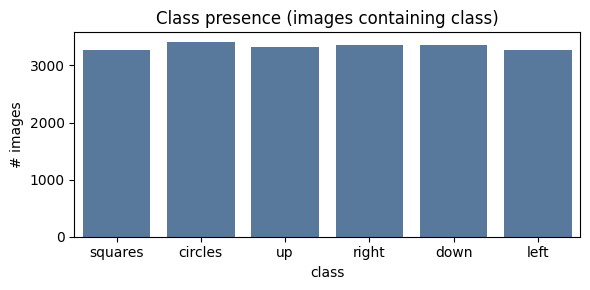

In [ ]:
present_counts = (df[label_cols] > 0).sum(axis=0).reindex(label_cols)

plt.figure(figsize=(6,3))
sns.barplot(x=label_cols, y=present_counts.values, color='#4C78A8')
plt.title('Class presence (images containing class)')
plt.ylabel('# images')
plt.xlabel('class')
plt.tight_layout()
plt.show()

## Smaller count barplot

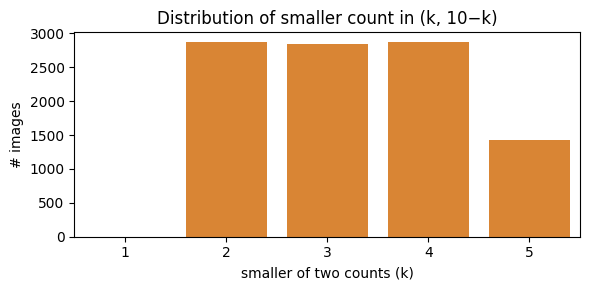

In [ ]:
smaller = []
for vals in df[label_cols].to_numpy(dtype=int):
    nz_vals = vals[vals > 0]
    smaller.append(int(min(nz_vals)))
freq = pd.Series(smaller).value_counts().reindex(range(1,6), fill_value=0).sort_index()

plt.figure(figsize=(6,3))
sns.barplot(x=list(freq.index), y=freq.values, color='#F58518')
plt.title('Distribution of smaller count in (k, 10−k)')
plt.xlabel('smaller of two counts (k)')
plt.ylabel('# images')
plt.tight_layout()
plt.show()

## 135 class heatmap

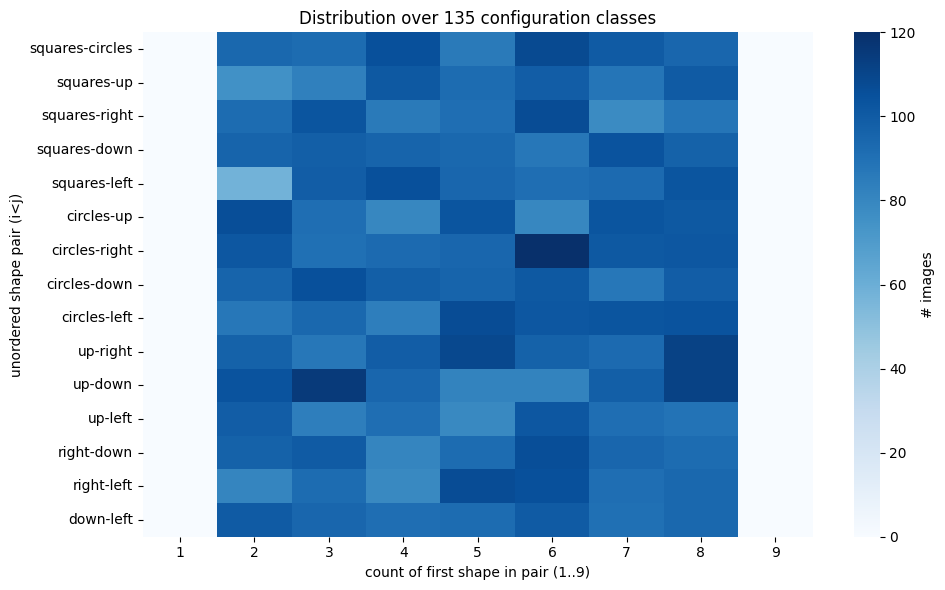

In [ ]:
pairs = [(i, j) for i in range(6) for j in range(i+1, 6)]
row_labels = [f"{label_cols[i]}-{label_cols[j]}" for (i, j) in pairs]
pair_to_row = {p: r for r, p in enumerate(pairs)}

freq = np.zeros((len(pairs), 9), dtype=int)
for vals in df[label_cols].to_numpy(dtype=int):
    i, j = sorted(np.flatnonzero(vals).tolist())
    r = pair_to_row[(i, j)]
    c = vals[i] - 1
    freq[r, c] += 1

plt.figure(figsize=(10, 6))
sns.heatmap(freq, cmap='Blues', annot=False,
            xticklabels=[str(k) for k in range(1,10)],
            yticklabels=row_labels, cbar_kws={'label': '# images'})
plt.xlabel('count of first shape in pair (1..9)')
plt.ylabel('unordered shape pair (i<j)')
plt.title('Distribution over 135 configuration classes')
plt.tight_layout()
plt.show()

## 135 class histogram

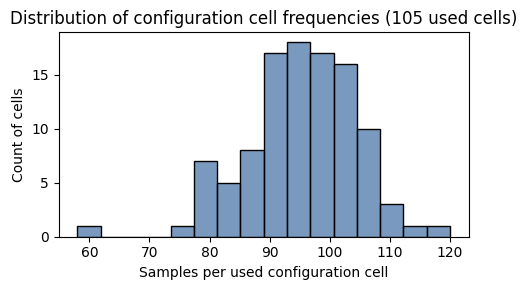

Min: 58 Max: 120 Mean: 95.23809523809524


In [ ]:
pairs = [(i, j) for i in range(6) for j in range(i+1, 6)]
pair_to_row = {p: r for r, p in enumerate(pairs)}

freq_135 = np.zeros((15, 9), dtype=int)
for vals in df[label_cols].to_numpy(dtype=int):
    nz = np.flatnonzero(vals)
    a, b = sorted(nz.tolist())
    row = pair_to_row[(a, b)]
    k = vals[nz[0]]  # first in CSV order
    col = k - 1
    freq_135[row, col] += 1

used_mask = freq_135 > 0
used_counts = freq_135[used_mask]

plt.figure(figsize=(5,3))
sns.histplot(used_counts, bins=16, color='#4C78A8')
plt.xlabel('Samples per used configuration cell')
plt.ylabel('Count of cells')
plt.title('Distribution of configuration cell frequencies (105 used cells)')
plt.tight_layout()
plt.show()

print("Min:", used_counts.min(), "Max:", used_counts.max(), "Mean:", used_counts.mean())

# Dataset class

## Helper functions

In [ ]:
IMG_H = 28
IMG_W = 28

# ---------- Geometric image transforms (flattened input) ----------
def hflip(x):
    """
    Horizontal flip (left-right).
    """
    return torch.flip(x, dims=(-1,))  # flip width

def vflip(x):
    """
    Vertical flip (top-bottom).
    """
    return torch.flip(x, dims=(-2,))  # flip height

def rot90(x, k=1):
    """
    Rotate 90° clockwise k times (k in {0,1,2,3}).
    Implemented as transpose + flip (no negative-step slicing).
    """
    k %= 4
    if k == 0:
        return x
    for _ in range(k):
        x = torch.flip(x.transpose(-2, -1), dims=(-1,))  # CW: transpose then flip columns
    return x

# ---------- Count label remaps ----------
# counts layout: [squares, circles, up, right, down, left]
IDX_HFLIP = torch.tensor([0, 1, 2, 5, 4, 3])  # right<->left
IDX_VFLIP = torch.tensor([0, 1, 4, 3, 2, 5])  # up<->down

def remap_hflip(counts):
    return counts[..., IDX_HFLIP]

def remap_vflip(counts):
    return counts[..., IDX_VFLIP]

def remap_rot90(counts, k=1):
    """
    Rotate orientation counts clockwise k times: up->right->down->left.
    """
    head = counts[..., :2]
    orient = counts[..., 2:6]
    orient = torch.roll(orient, shifts=k, dims=-1)  # CW shift
    return torch.cat([head, orient], dim=-1)

# ---------- Combined convenience ----------
def apply_geom(x_flat, counts6,
               do_h=False, do_v=False, k_rot=0):
    """
    Apply geometric transforms to flattened image and counts.
    Order: rotation -> hflip -> vflip (consistent remap).
    Returns (x_aug, counts_aug).
    """
    k_rot %= 4
    if k_rot:
        x_flat = rot90(x_flat, k_rot)
        counts6 = remap_rot90(counts6, k_rot)
    if do_h:
        x_flat = hflip(x_flat)
        counts6 = remap_hflip(counts6)
    if do_v:
        x_flat = vflip(x_flat)
        counts6 = remap_vflip(counts6)
    return x_flat, counts6

In [ ]:
def encode_counts_to_class135(counts: torch.Tensor) -> torch.Tensor:
    # counts shape (6,), exactly two non-zero entries
    nz = torch.nonzero(counts > 0, as_tuple=False).flatten()
    a, b = nz.sort().values.tolist()
    row = a * (11 - a) // 2 + (b - a - 1)   # unordered pair index
    col = int(counts[a].item()) - 1         # 0..8
    return torch.tensor(row * 9 + col, dtype=torch.long)

## CountsDataset

In [ ]:
from torch.utils.data import Dataset, DataLoader

DEFAULT_AUG = {
    "p_hflip": 0.5,
    "p_vflip": 0.5,
    "p_rot90": 0.75  # probability to apply a 90° rotation at least once
}

class CountsDataset(Dataset):
    """
    Preloads labels and images once in __init__:
      - counts: tensor [N, 6] (float32)
      - images: tensor [N, 28*28] (float32), binary in {0.0, 1.0}, flattened
    Returns:
      - x: (1, 28, 28) float32 in {0,1}
      - counts6: (6,) float32
      - cls135: () long (0..134)
    """
    def __init__(self, data_dir="data", labels_csv="data/labels.csv", indices=None, augment=None):
        self.data_dir = Path(data_dir)
        self.img_size = (IMG_H, IMG_W) # (28, 28)
        self.label_cols = ['squares','circles','up','right','down','left']

        # Parse augment config: None/False disables; True uses defaults; dict overrides defaults.
        if not augment:
            self.aug = None
        elif augment is True:
            self.aug = dict(DEFAULT_AUG)
        else:
            self.aug = dict(DEFAULT_AUG)
            self.aug.update(augment)

        # Read CSV rows
        rows = []
        with open(labels_csv, newline='') as f:
            reader = csv.DictReader(f)
            rows = list(reader)

        if indices is not None:
            rows = [rows[i] for i in indices]

        n = len(rows)
        H, W = self.img_size

        # Allocate tensors
        self.images = torch.empty((n, 1, H, W), dtype=torch.float32)
        self.counts = torch.empty((n, 6), dtype=torch.float32)
        self.names = []

        # Load and store
        for i, row in enumerate(rows):
            img_path = self.data_dir / row['name']
            img = Image.open(img_path).convert('L')
            if img.size != (W, H):
                img = img.resize((W, H), Image.NEAREST)

            arr = np.asarray(img, dtype=np.uint8, copy=True) # (H, W)
            arr = (arr > 128).astype(np.float32)
            self.images[i] = torch.from_numpy(arr).unsqueeze(0) # (1, H, W)
            self.counts[i] = torch.tensor([int(row[c]) for c in self.label_cols], dtype=torch.float32)
            self.names.append(row['name'])

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        x = self.images[idx]
        counts6 = self.counts[idx]

        if self.aug:
            do_h = bool(torch.rand(()) < self.aug["p_hflip"])
            do_v = bool(torch.rand(()) < self.aug["p_vflip"])
            k_rot = int(torch.randint(1, 4, (1,)).item()) if (torch.rand(()) < self.aug["p_rot90"]) else 0
            x, counts6 = apply_geom(x, counts6, do_h=bool(do_h), do_v=bool(do_v), k_rot=k_rot)

        x = x.view(1, IMG_H, IMG_W)
        cls135 = encode_counts_to_class135(counts6.to(torch.int64))
        return x, counts6, cls135

In [ ]:
# Example split and loaders
labels_csv = "data/labels.csv"
train_indices = list(range(0, 9000))
val_indices   = list(range(9000, 10000))

train_ds = CountsDataset(data_dir="data", labels_csv=labels_csv, indices=train_indices, augment=True)
val_ds   = CountsDataset(data_dir="data", labels_csv=labels_csv, indices=val_indices, augment=None)

# Use <=2 workers on this system; pin memory only if CUDA is available
use_cuda = torch.cuda.is_available()
num_workers = 2
pin_memory = bool(use_cuda)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=1000, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)

# quick sanity check
batch_x, batch_counts, batch_135s = next(iter(train_loader))
print("train batch x:", batch_x.shape, batch_x.dtype, "| counts:", batch_counts.shape, batch_counts.dtype, "| classes:", batch_135s.shape, batch_135s.dtype)
print("example row:", batch_x[0])

train batch x: torch.Size([64, 1, 28, 28]) torch.float32 | counts: torch.Size([64, 6]) torch.float32 | classes: torch.Size([64]) torch.int64
example row: tensor([[[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 0., 1., 1., 1., 0., 1., 1., 1.

# Model definition

## MultiTaskNetwork

In [ ]:
class MultiTaskNetwork(nn.Module):
    def __init__(self, drop_cls=0.3, drop_cnt=0.3):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(64 * 28 * 28, 256), nn.ReLU()
        )
        self.head_cls = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(),
            nn.Dropout(drop_cls),
            nn.Linear(256, 135),
            nn.LogSoftmax(dim=-1),
        )
        self.head_cnt = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(),
            nn.Dropout(drop_cnt),
            nn.Linear(256, 6),
        )

    def forward(self, x: Tensor):
        """
        x: (N, 1, 28, 28)
        returns:
          - log_probs: (N, 135)
          - counts:    (N, 6)
        """
        feat = self.backbone(x)
        log_probs = self.head_cls(feat)
        counts = self.head_cnt(feat)
        return log_probs, counts

# Training process

## Training helpers

In [ ]:
from copy import deepcopy

class EarlyStopping:
    def __init__(self, mode="min", patience=10, min_delta=0.0, restore_best=True):
        assert mode in ("min", "max")
        self.mode = mode
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best

        self.best = None
        self.best_state = None
        self.best_metrics = None
        self.best_epoch = -1
        self.num_bad_epochs = 0

    def _is_better(self, current, best):
        if self.mode == "min":
            return current < best - self.min_delta
        else:
            return current > best + self.min_delta

    def step(self, metrics, model, epoch_idx):
        current_value = metrics['val_loss']
        if self.best is None or self._is_better(current_value, self.best):
            self.best = current_value
            self.best_state = deepcopy(model.state_dict())
            self.best_metrics = metrics.copy()
            self.best_epoch = epoch_idx
            self.num_bad_epochs = 0
            return False  # do not stop
        else:
            self.num_bad_epochs += 1
            return self.num_bad_epochs > self.patience

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)

In [ ]:
class MultiTaskLoss(nn.Module):
    def __init__(self, lambda_cnt: float = 1.0, do_cls: bool = True):
        super().__init__()
        self.lambda_cls = 1.0 if do_cls else 0.0
        self.lambda_cnt = lambda_cnt
        self.nll = nn.NLLLoss()
        self.sl1 = nn.SmoothL1Loss()

    def forward(self, inputs, targets):
        # inputs: (log_probs, counts_pred)
        # targets: (cls135, counts)
        log_probs, counts_pred = inputs
        cls135, counts = targets

        zero = log_probs.new_zeros(())
        loss_cls = self.nll(log_probs, cls135) if self.lambda_cls > 0.0 else zero
        loss_cnt = self.sl1(counts_pred, counts) if self.lambda_cnt > 0.0 else zero
        return self.lambda_cls * loss_cls + self.lambda_cnt * loss_cnt

## Metrics helpers

In [ ]:
def macro_f1(cm: Tensor) -> float:
    tp = cm.diag().float()
    fp = cm.sum(0).float() - tp
    fn = cm.sum(1).float() - tp
    precision = tp / (tp + fp).clamp(min=1.0)
    recall    = tp / (tp + fn).clamp(min=1.0)
    f1 = 2 * precision * recall / (precision + recall).clamp(min=1e-8)
    return 100 * f1.mean().item()  # return as percentage

def pair_accuracy_matrix(cm: Tensor) -> dict:
    """
    Returns a 6x6 matrix M where M[i,j] = accuracy (%) of correctly predicting
    the unordered shape pair {i,j} ignoring counts (blocks of 9).
    Diagonal entries set to -1.
    Assumes class ordering: all (i,j) with i<j, each followed by its 9 count combos.
    """
    shapes = ['square','circle','up','right','down','left']
    pairs = [(i,j) for i in range(6) for j in range(i+1,6)]  # 15 blocks
    M = np.full((6,6), -1.0, dtype=np.float32)
    for block_idx,(a,b) in enumerate(pairs):
        start = block_idx * 9
        end = start + 9
        total = cm[start:end, :].sum().item()
        if total > 0:
            correct = cm[start:end, start:end].sum().item()
            acc = 100.0 * correct / total
        else:
            acc = 0.0
        M[a,b] = acc
        M[b,a] = acc
    return M

def format_pair_matrix(M: np.ndarray) -> str:
    shapes = ['square','circle','up','right','down','left']
    col_w = 9
    header = " " * (col_w) + "".join(f"{s:>{col_w}}" for s in shapes)
    rows = [header]
    for i,s in enumerate(shapes):
        line = f"{s:<{col_w}}"
        for j in range(6):
            if i == j:
                cell = "-"
            else:
                cell = f"{M[i,j]:.2f}"
            line += f"{cell:>{col_w}}"
        rows.append(line)
    return "\n".join(rows)

def print_metrics(epoch: int, metrics: dict, pair_acc=False):
    train_loss = metrics['train_loss']
    val_loss = metrics['val_loss']
    top1_acc = metrics['top1_acc']
    f1_macro = metrics['f1_macro']
    rmse = metrics['rmse']
    mae = metrics['mae']
    print(f"Epoch {epoch + 1:2d} | Train loss {train_loss:.4f}, Val loss {val_loss:.4f} | Acc {top1_acc:4.1f}%, F1 {f1_macro:4.1f}% | RMSE {rmse:.4f}, MAE {mae:.4f}")
    if pair_acc:
        print(format_pair_matrix(metrics['pair_acc_matrix']))

## MultiTaskTrainer



In [ ]:
class MultiTaskTrainer:
    def __init__(
        self,
        trainset_size: int = 9000,
        train_batch_size: int = 64,
        test_batch_size: int = 1000,
        use_cuda: bool = torch.cuda.is_available(),
    ) -> None:
        self.device = torch.device("cuda" if use_cuda else "cpu")

        train_indices = list(range(0, trainset_size))
        test_indices = list(range(trainset_size, 10000))

        self.trainset = CountsDataset(
            data_dir="data", labels_csv="data/labels.csv", indices=train_indices, augment=True
        )
        self.trainloader = DataLoader(
            self.trainset, batch_size=train_batch_size, shuffle=True, num_workers=2, pin_memory=use_cuda
        )

        self.testset = CountsDataset(
            data_dir="data", labels_csv="data/labels.csv", indices=test_indices, augment=None
        )
        self.testloader = DataLoader(
            self.testset, batch_size=test_batch_size, shuffle=False, num_workers=2, pin_memory=use_cuda
        )

    def train(
        self,
        net: nn.Module,
        num_epochs: int = 100,
        lr: float = 0.001,
        lambda_cnt: float = 1.0,
        do_cls: bool = True,
    ) -> None:
        optimizer = torch.optim.Adam(net.parameters(), lr=lr)
        LossCalc = MultiTaskLoss(lambda_cnt=lambda_cnt, do_cls=do_cls)
        stopper = EarlyStopping(mode="min", restore_best=True)
        metrics_history = []

        net.to(self.device)
        for epoch in range(num_epochs):
            net.train()
            train_loss_sum = 0.0
            seen = 0

            for i, data in enumerate(self.trainloader):
                inputs, counts, cls135 = [t.to(self.device, non_blocking=True) for t in data]

                optimizer.zero_grad()
                log_probs, counts_pred = net(inputs)
                loss = LossCalc((log_probs, counts_pred), (cls135, counts))
                loss.backward()
                optimizer.step()

                bs = inputs.size(0)
                train_loss_sum += float(loss.item()) * bs
                seen += bs

            metrics = self.test(net, LossCalc)
            metrics['train_loss'] = train_loss_sum / seen
            print_metrics(epoch, metrics)
            metrics_history.append(metrics)

            if stopper.step(metrics, net, epoch):
                print(f"Early stopping triggered at epoch {epoch + 1}.")
                break

        print(f"Restoring best model from epoch {stopper.best_epoch + 1}.")
        stopper.restore(net)
        print_metrics(stopper.best_epoch, stopper.best_metrics, pair_acc=True)

        return metrics_history

    def test(self, net: nn.Module, LossCalc: MultiTaskLoss) -> dict:
        net.eval()
        num_classes = 135

        cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
        sse = 0.0
        abs_err_sum = 0.0
        loss_sum = 0.0

        with torch.no_grad():
            for data in self.testloader:
                inputs, counts, cls135 = [t.to(self.device, non_blocking=True) for t in data]
                log_probs, counts_pred = net(inputs)

                bs = cls135.size(0)
                loss = LossCalc((log_probs, counts_pred), (cls135, counts))
                loss_sum += loss * bs

                # Update confusion matrix
                predicted = log_probs.argmax(dim=1)
                flat_idx = cls135 * num_classes + predicted
                cm += torch.bincount(flat_idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes).cpu()

                err = counts_pred - counts
                sse += err.pow(2).sum().item()
                abs_err_sum += err.abs().sum().item()

        total = cm.sum().item()
        result = {
            'top1_acc': 100.0 * cm.diag().sum().item() / total,
            'f1_macro': macro_f1(cm),
            'rmse': np.sqrt(sse / (total * 6)),
            'mae': abs_err_sum / (total * 6),
            'val_loss': loss_sum / total,
            'pair_acc_matrix': pair_accuracy_matrix(cm)
        }

        return result

# Model training

## Classification only

In [ ]:
model = MultiTaskNetwork()
trainer = MultiTaskTrainer(
    trainset_size=9000,
    train_batch_size=64,
    test_batch_size=1000,
    use_cuda=torch.cuda.is_available(),
)

start_time = time.perf_counter()
cls_only_metrics = trainer.train(
    net=model,
    num_epochs=100,
    lr=0.001,
    lambda_cnt=0.0,
    do_cls=True,
)
elapsed = time.perf_counter() - start_time
print(f"Classification only training runtime: {elapsed:.2f}s")

Epoch  1 | Train loss 4.7318, Val loss 4.6834 | Acc  1.0%, F1  0.0% | RMSE 3.1186, MAE 1.6949
Epoch  2 | Train loss 4.6765, Val loss 4.6667 | Acc  1.0%, F1  0.0% | RMSE 3.1221, MAE 1.6990
Epoch  3 | Train loss 4.5795, Val loss 4.0796 | Acc  3.4%, F1  0.3% | RMSE 3.1252, MAE 1.7310
Epoch  4 | Train loss 3.8715, Val loss 3.6367 | Acc  5.5%, F1  0.8% | RMSE 3.1437, MAE 1.7464
Epoch  5 | Train loss 3.5484, Val loss 3.1866 | Acc  7.3%, F1  2.1% | RMSE 3.1835, MAE 1.8184
Epoch  6 | Train loss 3.0861, Val loss 2.9044 | Acc 12.1%, F1  4.8% | RMSE 3.1807, MAE 1.8244
Epoch  7 | Train loss 2.8967, Val loss 2.6967 | Acc 12.2%, F1  5.3% | RMSE 3.1997, MAE 1.8654
Epoch  8 | Train loss 2.7754, Val loss 2.6518 | Acc 15.0%, F1  6.7% | RMSE 3.2096, MAE 1.8701
Epoch  9 | Train loss 2.6208, Val loss 2.4262 | Acc 18.4%, F1  8.9% | RMSE 3.2010, MAE 1.8737
Epoch 10 | Train loss 2.4865, Val loss 2.3591 | Acc 20.2%, F1 11.4% | RMSE 3.2163, MAE 1.8928
Epoch 11 | Train loss 2.2992, Val loss 2.0811 | Acc 29.1%, F

## Regression only

In [ ]:
model = MultiTaskNetwork()
trainer = MultiTaskTrainer(
    trainset_size=9000,
    train_batch_size=64,
    test_batch_size=1000,
    use_cuda=torch.cuda.is_available(),
)

start_time = time.perf_counter()
reg_only_metrics = trainer.train(
    net=model,
    num_epochs=100,
    lr=0.001,
    lambda_cnt=1.0,
    do_cls=False,
)
elapsed = time.perf_counter() - start_time
print(f"Regression only training runtime: {elapsed:.2f}s")

Epoch  1 | Train loss 1.4160, Val loss 1.3836 | Acc  0.6%, F1  0.0% | RMSE 2.7756, MAE 1.7748
Epoch  2 | Train loss 1.1188, Val loss 0.7707 | Acc  0.6%, F1  0.0% | RMSE 1.8761, MAE 1.0908
Epoch  3 | Train loss 0.6949, Val loss 0.5856 | Acc  0.6%, F1  0.0% | RMSE 1.4880, MAE 0.8721
Epoch  4 | Train loss 0.4600, Val loss 0.3000 | Acc  0.8%, F1  0.1% | RMSE 0.9137, MAE 0.5453
Epoch  5 | Train loss 0.3277, Val loss 0.2896 | Acc  0.6%, F1  0.0% | RMSE 0.8929, MAE 0.5212
Epoch  6 | Train loss 0.2963, Val loss 0.2380 | Acc  0.7%, F1  0.1% | RMSE 0.7913, MAE 0.4462
Epoch  7 | Train loss 0.2669, Val loss 0.2252 | Acc  0.6%, F1  0.0% | RMSE 0.7619, MAE 0.4275
Epoch  8 | Train loss 0.2522, Val loss 0.2191 | Acc  0.6%, F1  0.0% | RMSE 0.7522, MAE 0.4213
Epoch  9 | Train loss 0.2440, Val loss 0.2109 | Acc  0.6%, F1  0.0% | RMSE 0.7334, MAE 0.4020
Epoch 10 | Train loss 0.2337, Val loss 0.2398 | Acc  0.6%, F1  0.0% | RMSE 0.8003, MAE 0.4378
Epoch 11 | Train loss 0.2245, Val loss 0.2013 | Acc  0.6%, F

## Multitask

In [ ]:
model = MultiTaskNetwork()
trainer = MultiTaskTrainer(
    trainset_size=9000,
    train_batch_size=64,
    test_batch_size=1000,
    use_cuda=torch.cuda.is_available(),
)

start_time = time.perf_counter()
multitask_metrics = trainer.train(
    net=model,
    num_epochs=100,
    lr=0.001,
    lambda_cnt=2.0,
    do_cls=True,
)
elapsed = time.perf_counter() - start_time
print(f"Multitask training runtime: {elapsed:.2f}s")

Epoch  1 | Train loss 7.5312, Val loss 7.2048 | Acc  1.9%, F1  0.3% | RMSE 2.7393, MAE 1.7218
Epoch  2 | Train loss 6.2696, Val loss 5.5759 | Acc  6.4%, F1  1.9% | RMSE 2.2147, MAE 1.3575
Epoch  3 | Train loss 5.0125, Val loss 4.0618 | Acc 16.0%, F1  7.5% | RMSE 1.5925, MAE 0.9670
Epoch  4 | Train loss 3.7120, Val loss 2.9978 | Acc 23.3%, F1 12.5% | RMSE 1.1879, MAE 0.6928
Epoch  5 | Train loss 2.9554, Val loss 2.5764 | Acc 28.5%, F1 16.3% | RMSE 1.0232, MAE 0.6089
Epoch  6 | Train loss 2.6397, Val loss 2.3336 | Acc 34.1%, F1 21.6% | RMSE 0.9349, MAE 0.5411
Epoch  7 | Train loss 2.4382, Val loss 2.2583 | Acc 33.5%, F1 20.7% | RMSE 0.8829, MAE 0.5186
Epoch  8 | Train loss 2.2818, Val loss 2.0955 | Acc 38.1%, F1 24.4% | RMSE 0.8160, MAE 0.4897
Epoch  9 | Train loss 2.1388, Val loss 2.0625 | Acc 36.6%, F1 23.3% | RMSE 0.7891, MAE 0.4478
Epoch 10 | Train loss 2.0472, Val loss 1.9023 | Acc 36.9%, F1 24.3% | RMSE 0.7238, MAE 0.4179
Epoch 11 | Train loss 1.9876, Val loss 2.0128 | Acc 37.5%, F

# Training plots

## Plotting helpers

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

def _as_float(v):
    if isinstance(v, torch.Tensor):
        return float(v.detach().cpu().item())
    return None if v is None else float(v)

def metrics_to_df(metrics_list):
    rows = []
    for i, m in enumerate(metrics_list):
        rows.append({
            "epoch": m.get("epoch", i),
            "train_loss": _as_float(m.get("train_loss")),
            "val_loss": _as_float(m.get("val_loss")),
            "top1_acc": _as_float(m.get("top1_acc")),
            "f1_macro": _as_float(m.get("f1_macro")),
            "rmse": _as_float(m.get("rmse")),
            "mae": _as_float(m.get("mae")),
        })
    return pd.DataFrame(rows)

def plot_cls(metrics_list, savepath=None):
    """
    Classification-focused: loss + (accuracy & macro F1).
    """
    df = metrics_to_df(metrics_list)
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    # Loss
    ax[0].plot(df.epoch, df.train_loss, label="Train")
    ax[0].plot(df.epoch, df.val_loss, label="Val")
    ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
    ax[0].legend(); ax[0].grid(alpha=0.3)

    # Acc & F1
    ax[1].plot(df.epoch, df.top1_acc, label="Top-1 Acc", color="tab:blue")
    ax[1].plot(df.epoch, df.f1_macro, label="Macro F1", color="tab:green")
    ax[1].set_title("Accuracy & F1"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Score")
    ax[1].legend(); ax[1].grid(alpha=0.3)
    fig.tight_layout()
    if savepath: fig.savefig(savepath, bbox_inches="tight")

def plot_reg(metrics_list, savepath=None):
    """
    Regression-focused: loss + (RMSE & MAE).
    """
    df = metrics_to_df(metrics_list)
    fig, ax = plt.subplots(1,2, figsize=(10,4))

    # Loss
    ax[0].plot(df.epoch, df.train_loss, label="Train")
    ax[0].plot(df.epoch, df.val_loss, label="Val")
    ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
    ax[0].legend(); ax[0].grid(alpha=0.3)

    # RMSE & MAE
    ax[1].plot(df.epoch, df.rmse, label="RMSE", color="tab:orange")
    ax[1].plot(df.epoch, df.mae, label="MAE", color="tab:red")
    ax[1].set_title("RMSE & MAE"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Error")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    fig.tight_layout()
    if savepath: fig.savefig(savepath, bbox_inches="tight")

def plot_all(metrics_list, savepath=None):
    """
    Three plots: top-left (Loss), top-right (Acc & F1), bottom (RMSE & MAE) centered.
    """
    df = metrics_to_df(metrics_list)
    fig = plt.figure(figsize=(10,7))
    gs = fig.add_gridspec(2, 2, height_ratios=[1,0.9])

    ax_loss = fig.add_subplot(gs[0,0])
    ax_reg = fig.add_subplot(gs[0,1])

    # Manually add centered bottom axis (same width as a top axis)
    # Determine width from top-left axis, then center horizontally.
    top_pos = ax_loss.get_position()
    axis_width = top_pos.width
    bottom_height = top_pos.height * 0.9
    # Center: (1 - axis_width)/2 for left x.
    left = (1.0 - axis_width) / 2.0
    bottom = 0.07  # adjust vertical placement
    ax_cls = fig.add_axes([left, bottom, axis_width, bottom_height])

    # Loss
    ax_loss.plot(df.epoch, df.train_loss, label="Train")
    ax_loss.plot(df.epoch, df.val_loss, label="Val")
    ax_loss.set_title("Loss"); ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

    # RMSE & MAE centered
    ax_reg.plot(df.epoch, df.rmse, label="RMSE", color="tab:orange")
    ax_reg.plot(df.epoch, df.mae, label="MAE", color="tab:red")
    ax_reg.set_title("RMSE & MAE"); ax_reg.set_xlabel("Epoch"); ax_reg.set_ylabel("Error")
    ax_reg.legend(); ax_reg.grid(alpha=0.3)

    # Acc & F1
    ax_cls.plot(df.epoch, df.top1_acc, label="Top-1 Acc", color="tab:blue")
    ax_cls.plot(df.epoch, df.f1_macro, label="Macro F1", color="tab:green")
    ax_cls.set_title("Acc & F1"); ax_cls.set_xlabel("Epoch"); ax_cls.set_ylabel("Score")
    ax_cls.legend(); ax_cls.grid(alpha=0.3)

    if savepath: fig.savefig(savepath, bbox_inches="tight")

## Plots

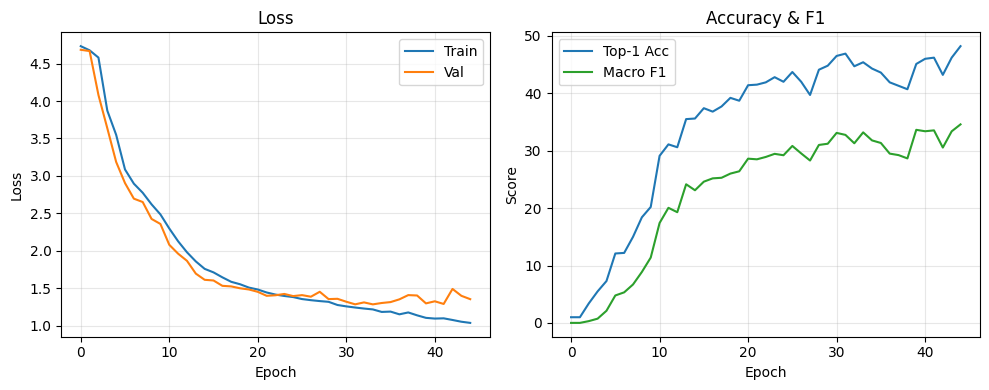

In [ ]:
plot_cls(cls_only_metrics)

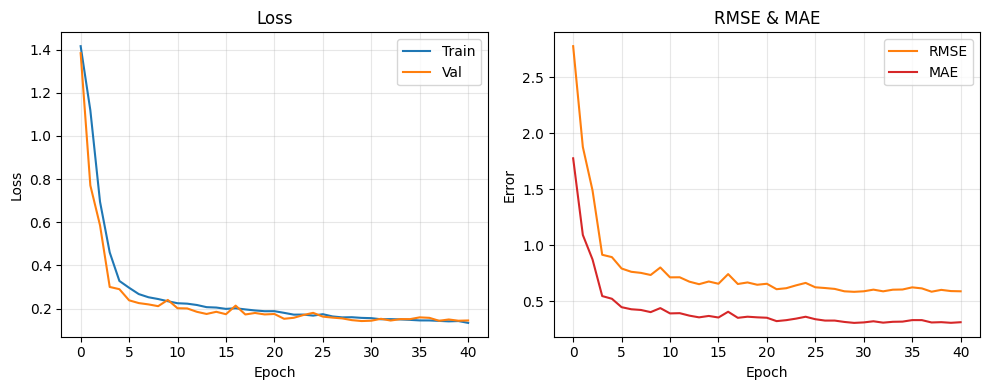

In [ ]:
plot_reg(reg_only_metrics)

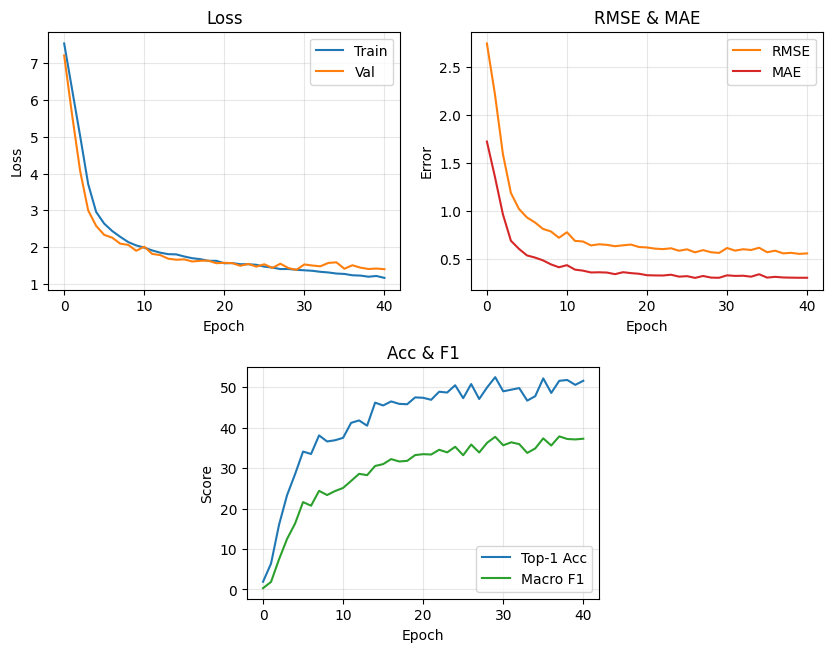

In [ ]:
plot_all(multitask_metrics)